# Naive LDS (no GP prior)

> **Engine class: Free SSM (no GP)** - `mbrila.LDS` with learnable $(A, Q)$. No GP kernel at all; the latent prior is a generic linear-Gaussian Markov chain. Baseline for the GP-prior models.


Fits `mbrila.LDS` - a multi-region linear dynamical system with **no Gaussian-Process prior** on the latents. The latent state is a flat $K$-dim Markov chain driven by learnable $(A, Q)$. Useful as a baseline against GP-prior models (DLAG / GPFA / mDLAG / ADM).

Scenario: same 5-region multi-region setup as the GP-prior demos. LDS has no across/within structure - we just pick a flat `n_latent = 7` (matches the `examples/demo_lds.py` CLI default), generous enough to absorb both kinds of truth latent.

The notebook produces three figures: convergence, PSTH heatmap, and trial-0 reconstruction. LDS doesn't have inter-region delays or a per-region latent decomposition, so the delay / per-latent-trace figures are omitted.

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch
from mbrila import LDS, KalmanEMEngine
from mbrila.synthetic.multiregion import MultiRegionScenario

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## Scenario

In [2]:
n_trials, T, n_regions = 50, 200, 5
y_dim_per_region, n_across, n_within = 100, 2, 1
sigma_across, sigma_within = 0.05, 0.05
delay_amplitude = 3.0
per_latent_sigma_ratio, per_latent_amp_ratio = 10.0, 3.0

scenario = MultiRegionScenario(  # noqa: F821
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=n_across,
    n_within=n_within,
    lag_across=2,
    lag_within=2,
    sigma_across=sigma_across,
    sigma_within=sigma_within,
    delay_shape="constant",
    delay_amplitude=delay_amplitude,
    per_latent_amplitudes=tuple(
        delay_amplitude * (1.0 / per_latent_amp_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_shapes=tuple(["constant"] * n_across),
    region_heterogeneity=1.0,
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}"
)

data.y shape = (50, 200, 500)
truth['delay'] shape = (200, 4, 2)
truth['observable'] shape = (50, 200, 15)


## Build & fit model

In [3]:
# LDS has a flat latent state with no across/within structure. Pick
# n_latent generous enough to absorb both kinds of truth latent -
# matches the demo_lds.py CLI default.
n_latent = 7

engine = KalmanEMEngine(
    lr=1e-2,
    lr_min=1e-3,
    weight_decay=1e-2,
    log_every=25,
)
model = LDS(
    n_latent=n_latent,
    y_dims=scenario.y_dims,
    T=scenario.T,
    engine=engine,
    device=device,
    dtype=torch.float64,
).to(device)

# pCCA emission init (LDS doesn't ship its own initialize_from_data).
demo.init_linear_observation_pcca(model, data, n_across=n_latent, n_within=0)

result = model.fit(data, max_iter=300, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[kalman_em] iter 25/300  E_q[log p(x,y)] = 331245.234


[kalman_em] iter 50/300  E_q[log p(x,y)] = 333183.393


[kalman_em] iter 75/300  E_q[log p(x,y)] = 334194.866


[kalman_em] iter 100/300  E_q[log p(x,y)] = 333742.301


[kalman_em] iter 125/300  E_q[log p(x,y)] = 333659.217


...

[kalman_em] iter 200/300  E_q[log p(x,y)] = 333407.649


[kalman_em] iter 225/300  E_q[log p(x,y)] = 333360.624


[kalman_em] iter 250/300  E_q[log p(x,y)] = 333327.709


[kalman_em] iter 275/300  E_q[log p(x,y)] = 333304.894


[kalman_em] iter 300/300  E_q[log p(x,y)] = 333287.483
fit done: 300 iters, wall = 56.8s


## Extract reconstruction

LDS has no across/within decomposition or per-region delay, so we skip the delay and latent-trace figures. Only the PSTH and single-trial reconstruction make sense here - same metrics as the other notebooks, on the same observed $y$.

In [4]:
fitted_y = demo.extract_y_recon(model, data)
print(f"fitted_y shape = {fitted_y.shape}")

fitted_y shape = (50, 200, 500)


## Figure 1 - Convergence

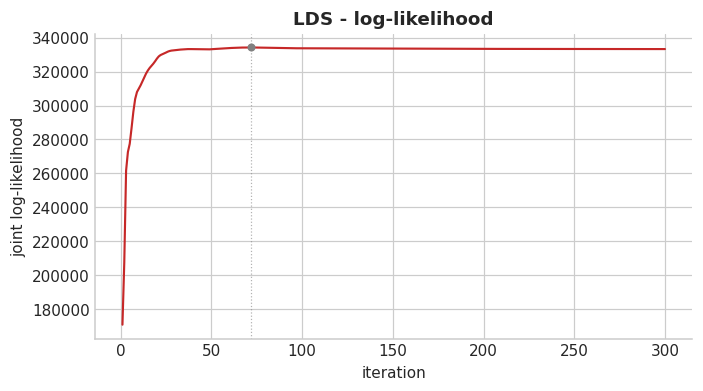

In [5]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="LDS - log-likelihood")

## Figure 2 - PSTH matrix comparison

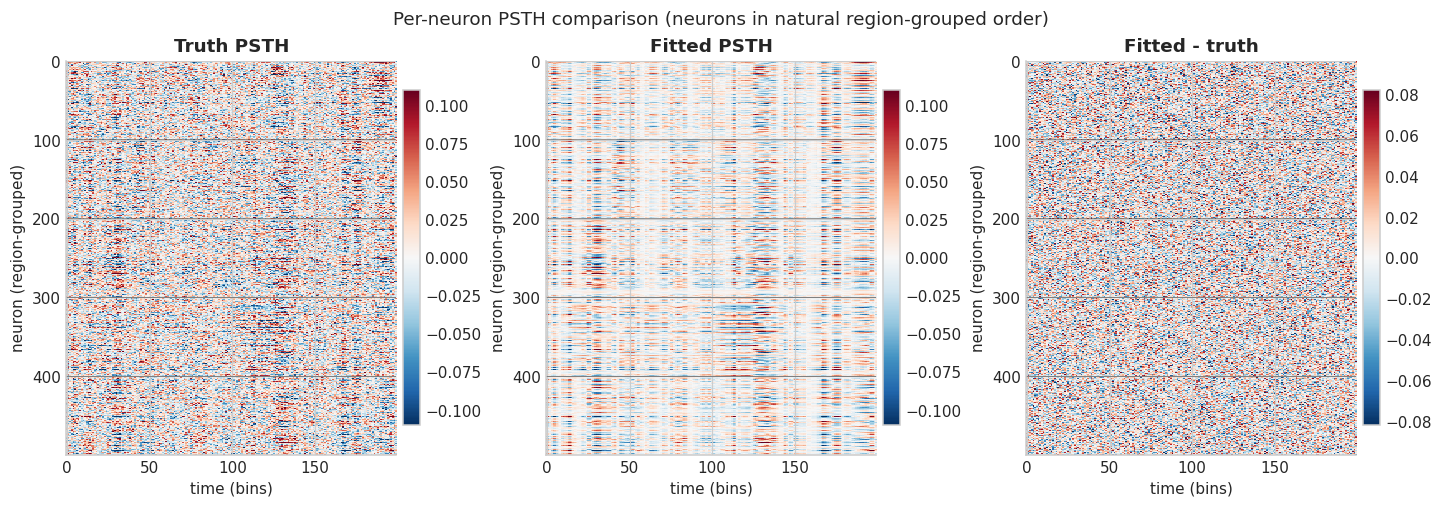

In [6]:
_ = nb.plot_psth_matrix(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
)

## Figure 3 - Trial-0 reconstruction

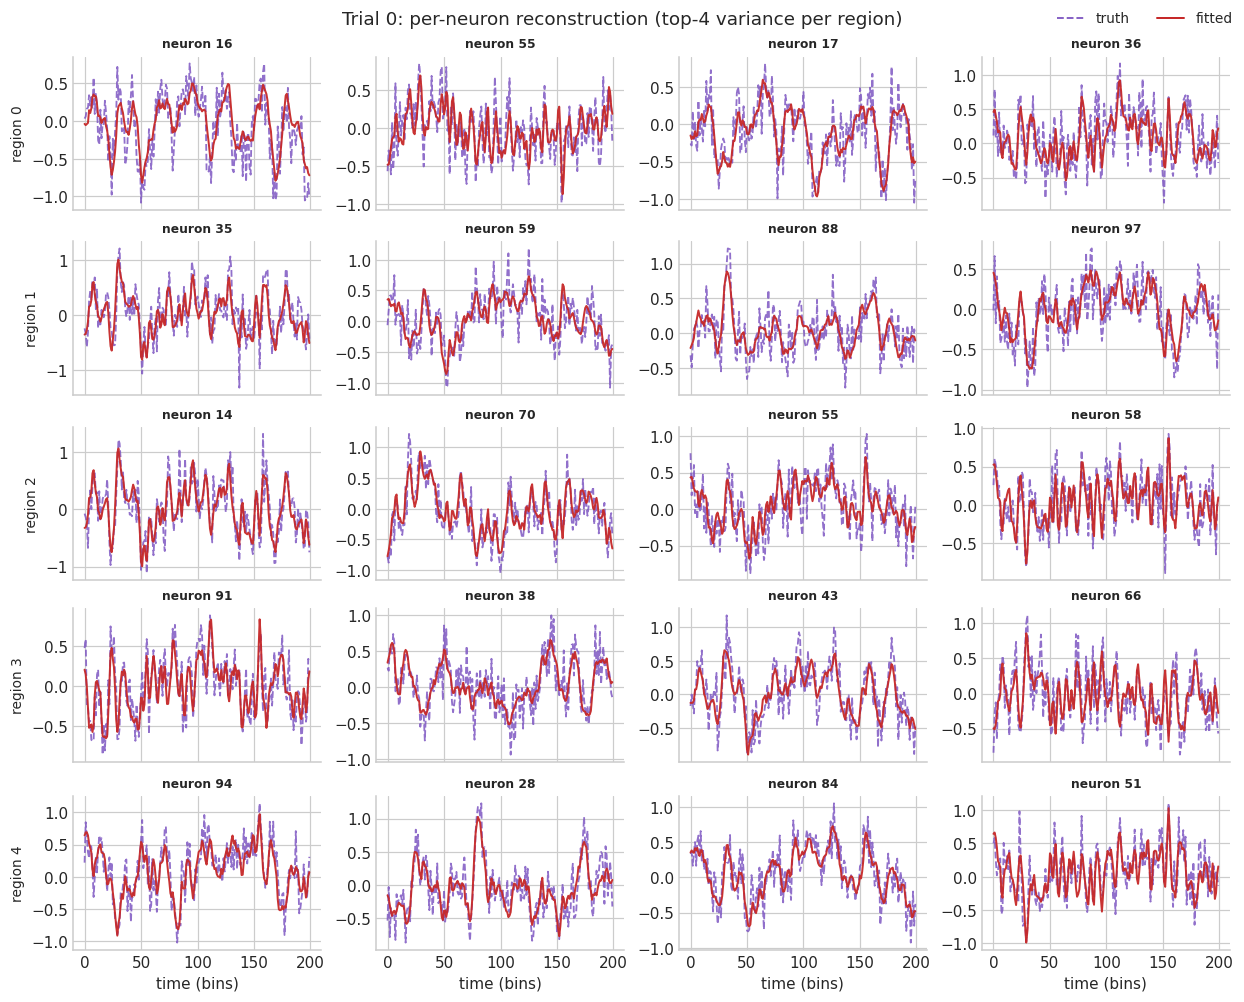

In [7]:
_ = nb.plot_trial0(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
    trial=0,
    n_per_region=4,
)

## Summary

In [8]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"y_rmse (overall)  = {y_info['overall']:.4f}")
print(f"y_rmse per region = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"wall time         = {result.wall_time_s:.1f}s")

y_rmse (overall)  = 0.2244
y_rmse per region = ['0.2293', '0.2249', '0.2232', '0.2222', '0.2226']
wall time         = 56.8s
